## Import Libraries

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [60]:
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Understand Data

In [61]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [62]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [63]:
train.isnull().sum().sort_values(ascending=False).head(10)

PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
MasVnrType      872
FireplaceQu     690
LotFrontage     259
GarageYrBlt      81
GarageCond       81
GarageType       81
dtype: int64

## Separate Input & Output

In [64]:
X = train.drop("SalePrice", axis=1)
y = train["SalePrice"]

## Handle Missing Values

In [65]:
# Fill numeric values with mean
X = X.fillna(X.mean(numeric_only=True))

# Fill categorical with most frequent value
X = X.fillna(X.mode().iloc[0])

## Convert Text → Numbers

In [66]:
X = pd.get_dummies(X)
test = pd.get_dummies(test)

## Align Train & Test Columns

In [67]:
X, test = X.align(test, join='left', axis=1, fill_value=0)

## Split Data

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Train Model

In [69]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## Predict & Evaluate

In [70]:
from sklearn.metrics import mean_squared_error

y_pred = model.predict(X_val)

print("MSE:", mean_squared_error(y_val, y_pred))

MSE: 873794723.7058048


## Fill Missing Values in TEST

In [71]:
# Fill numeric columns
test = test.fillna(test.mean(numeric_only=True))

# Fill categorical columns
test = test.fillna(test.mode().iloc[0])

## Align Columns

In [72]:
X, test = X.align(test, join='left', axis=1, fill_value=0)

## Output

In [73]:
print(test.isnull().sum().sum())

0


## Predict Test Data

In [74]:
final_predictions = model.predict(test)

## Create Submission File

In [75]:
submission = pd.DataFrame({
    "Id": pd.read_csv("data/test.csv")["Id"],
    "SalePrice": final_predictions
})

submission.to_csv("submission.csv", index=False)

## Import Metrics

In [76]:
from sklearn.metrics import mean_squared_error, r2_score

## Validation Predictions

In [77]:
mse = mean_squared_error(y_val, y_pred)
print("MSE:", mse)

MSE: 873794723.7058048


## Data Visualization

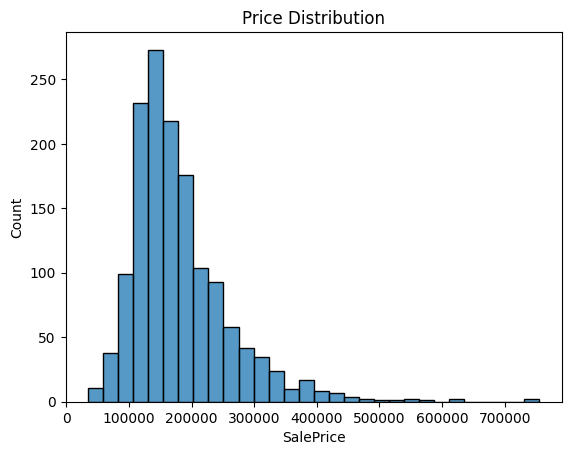

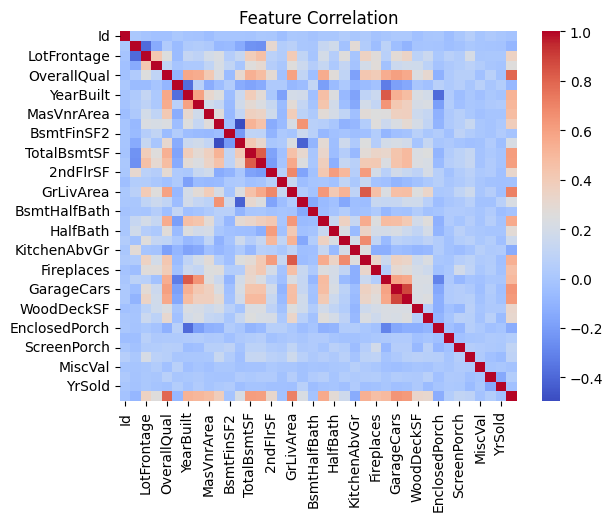

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribution of target
sns.histplot(y, bins=30)
plt.title("Price Distribution")
plt.show()

# Correlation heatmap
sns.heatmap(train.corr(numeric_only=True), cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

## Normalization

In [79]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

## R² Score

In [80]:
from sklearn.metrics import r2_score

print("R2 Score:", r2_score(y_val, y_pred))

R2 Score: 0.8860811522087475


## Actual vs Predicted Graph

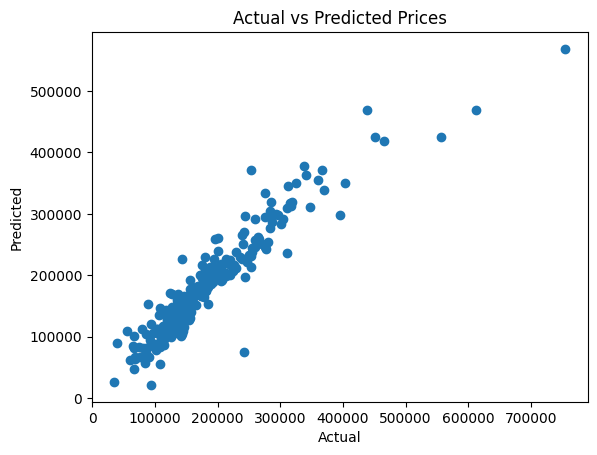

In [81]:
plt.scatter(y_val, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Prices")
plt.show()

## Random Forest

In [82]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_val)
print("RF MSE:", mean_squared_error(y_val, rf_pred))

RF MSE: 840773382.8969721


## Conclusion

# In this project, we built a House Price Prediction model using a regression approach.
We started by loading and exploring the dataset to understand feature distributions and relationships. Missing values were
handled appropriately, and categorical variables were converted into numerical format using encoding techniques. 
Feature scaling was applied to normalize the data.

The dataset was then split into training and validation sets. A Linear Regression model was trained on the processed data and 
evaluated using Mean Squared Error (MSE) and R² Score.
The results show that the model is capable of capturing the relationship between input features and house prices to a reasonable extent. 
Additionally, visualization of actual vs predicted values helped in understanding model performance.
Overall, this project demonstrates the complete machine learning workflow, including data preprocessing, model training, evaluation, and prediction.

# Skills Gained
- Data preprocessing and cleaning
- Handling missing values
- Feature engineering and encoding
- Regression modeling
- Model evaluation using MSE and R²
- Working with real-world tabular datasets